In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("creditcard.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset loaded successfully!
Shape: (19898, 31)

Columns:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [3]:
print("First 5 rows:")
print(df.head())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

First 5 rows:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0     0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1     0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2     1 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3     1 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4     2 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       

In [4]:
print("Class Distribution:")
print(df['Class'].value_counts())

print("\nPercentage Distribution:")
print(df['Class'].value_counts(normalize=True) * 100)

Class Distribution:
Class
0.0    19812
1.0       85
Name: count, dtype: int64

Percentage Distribution:
Class
0.0    99.5728
1.0     0.4272
Name: proportion, dtype: float64


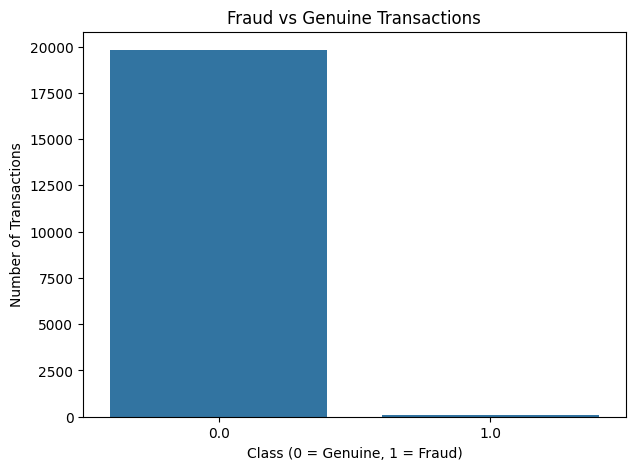

In [5]:
plt.figure(figsize=(7, 5))

sns.countplot(x='Class', data=df)

plt.title('Fraud vs Genuine Transactions')
plt.xlabel('Class (0 = Genuine, 1 = Fraud)')
plt.ylabel('Number of Transactions')

plt.show()

In [6]:
# Input features
X = df.drop('Class', axis=1)

# Target variable
y = df['Class']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget values:")
print(y.value_counts())

Features shape: (19898, 30)
Target shape: (19898,)

Target values:
Class
0.0    19812
1.0       85
Name: count, dtype: int64


In [8]:
print("Missing values:")
print(X.isnull().sum().sum())

Missing values:
19


In [9]:
print(X.isnull().sum()[X.isnull().sum() > 0])

V11       1
V12       1
V13       1
V14       1
V15       1
V16       1
V17       1
V18       1
V19       1
V20       1
V21       1
V22       1
V23       1
V24       1
V25       1
V26       1
V27       1
V28       1
Amount    1
dtype: int64


In [10]:
# Remove rows containing missing values
df = df.dropna()

# Recreate X and y
X = df.drop('Class', axis=1)
y = df['Class']

print("Missing values remaining:", X.isnull().sum().sum())
print("New dataset shape:", df.shape)

Missing values remaining: 0
New dataset shape: (19897, 31)


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training data: (15917, 30)
Testing data: (3980, 30)

Training class distribution:
Class
0.0    15849
1.0       68
Name: count, dtype: int64

Testing class distribution:
Class
0.0    3963
1.0      17
Name: count, dtype: int64


In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[['Time', 'Amount']] = scaler.fit_transform(
    X_train[['Time', 'Amount']]
)

X_test[['Time', 'Amount']] = scaler.transform(
    X_test[['Time', 'Amount']]
)

print("Feature scaling completed!")

Feature scaling completed!


In [13]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [14]:
y_pred = model.predict(X_test)

print("Predictions completed!")

print("\nFirst 20 Actual Values:")
print(y_test.values[:20])

print("\nFirst 20 Predicted Values:")
print(y_pred[:20])

Predictions completed!

First 20 Actual Values:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

First 20 Predicted Values:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [15]:
y_pred = model.predict(X_test)

print("Predictions completed!")

print("\nFirst 20 Actual Values:")
print(y_test.values[:20])

print("\nFirst 20 Predicted Values:")
print(y_pred[:20])

Predictions completed!

First 20 Actual Values:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

First 20 Predicted Values:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Model Evaluation:")
print("Accuracy  :", accuracy)
print("Precision :", precision)
print("Recall    :", recall)
print("F1-Score  :", f1)

Model Evaluation:
Accuracy  : 0.9979899497487437
Precision : 0.8461538461538461
Recall    : 0.6470588235294118
F1-Score  : 0.7333333333333333


In [17]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[3961    2]
 [   6   11]]


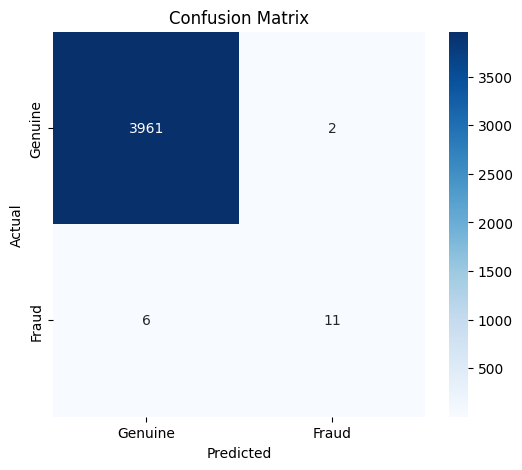

In [18]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Genuine', 'Fraud'],
    yticklabels=['Genuine', 'Fraud']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

In [19]:
import joblib

joblib.dump(model, "credit_card_fraud_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [20]:
from google.colab import files

files.download("credit_card_fraud_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>